In [2]:
import pandas as pd
import os
df = pd.read_csv("ML_dataset2.csv")
df.head()

,Country,Year,Precipitation,River Flow,Soil Water,Surface Water,Terr Water Storage,Vegetation Avg,Water Bodies,Avg Temp,Water Stress,Population Growth,Freshwater Resources,GDP,Overall Water Withdrawals,Dom Wuthdrawls,Political Violence
0,Algeria,2001,52.0,22.998,0.100000,NaN,NaN,0.117250,2099.032,24.18333,81.71,1.373291,358.971009,1776.949446,51.633028,31.40793,155.0
1,Algeria,2002,61.0,20.755,0.103333,NaN,-1.000000,0.115583,1835.018,23.87500,85.04,1.330395,354.226905,1751.911234,53.735272,31.96875,210.0
2,Algeria,2003,99.0,23.075,0.107500,0.000121,2.333333,0.120667,2119.552,23.85833,87.52,1.329615,349.548223,1793.094603,55.305819,32.48746,158.0
3,Algeria,2004,94.0,21.668,0.107500,0.000125,3.000000,0.122333,2149.398,23.51667,90.01,1.396440,344.700914,2116.689481,56.876366,32.96862,96.0
4,Algeria,2005,73.0,21.193,0.105833,0.000080,-6.500000,0.120083,1926.585,23.88333,92.49,1.463309,339.693600,2627.289243,58.446912,33.41618,78.0


## Cleaning Data

In [3]:
df.columns = df.columns.str.strip()

df["Country"] = df["Country"].str.replace(
    "Eswatini (formerly Swaziland)", "Eswatini"
)

df["Water Stress"] = (
    df["Water Stress"]
    .astype(str)
    .str.replace("*", "", regex=False)
    .str.strip()
    .replace(["", "nan", "None"], pd.NA)
)

df = df.dropna(how="all")
df.shape

(1350, 17)

In [4]:
df['Water Stress'] = df['Water Stress'].astype(str).str.replace('* ', '', regex=False)
df['Water Stress'] = pd.to_numeric(df['Water Stress'], errors='coerce')

In [5]:
df.columns = df.columns.str.strip()
df = df.sort_values('Year').reset_index(drop=True)
df.head()

,Country,Year,Precipitation,River Flow,Soil Water,Surface Water,Terr Water Storage,Vegetation Avg,Water Bodies,Avg Temp,Water Stress,Population Growth,Freshwater Resources,GDP,Overall Water Withdrawals,Dom Wuthdrawls,Political Violence
0,Algeria,2001,52.0,22.998,0.100000,NaN,NaN,0.117250,2099.032000,24.183330,81.71,1.373291,358.971009,1776.949446,51.633028,31.40793,155.0
1,Guinea,2001,1628.0,165.7641667,0.222500,NaN,NaN,0.589583,1075.440000,25.983333,0.89,1.309811,26463.824200,367.607995,0.246460,37.96060,59.0
2,Tunisia,2001,139.0,NaN,0.146667,NaN,NaN,0.152667,2239.109167,21.333333,66.02,1.066922,425.039239,2222.649893,66.960667,13.82576,3.0
3,Sao Tome and Principe,2001,1779.0,NaN,NaN,NaN,NaN,8.228000,NaN,25.491667,0.79,1.623353,14893.253600,NaN,0.861986,NaN,NaN
4,Ghana,2001,925.0,95.13083333,0.215000,NaN,NaN,0.528333,94922.146670,27.366667,4.28,2.663105,NaN,261.609671,3.330446,NaN,7.0


## EDA

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

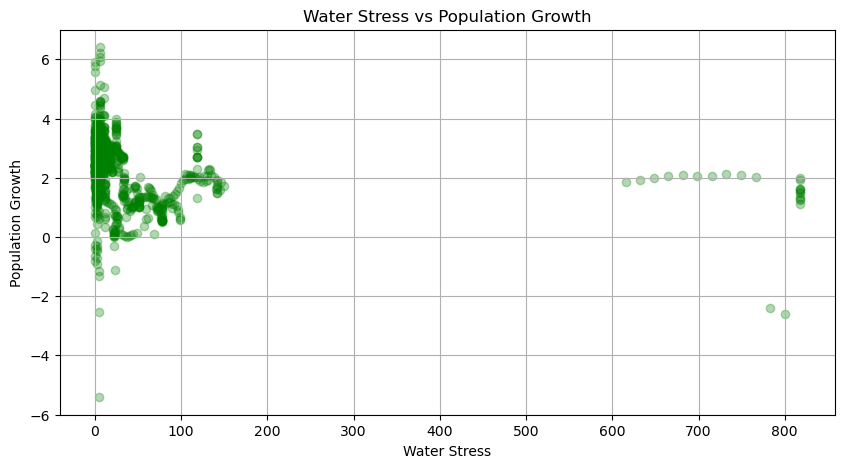

In [21]:
plt.figure(figsize=(10,5))
plt.scatter(df["Water Stress"], df["Population Growth"], c='Green', alpha=0.3)
plt.title("Water Stress vs Population Growth")
plt.xlabel("Water Stress")
plt.ylabel("Population Growth")
plt.grid(True)
plt.show()

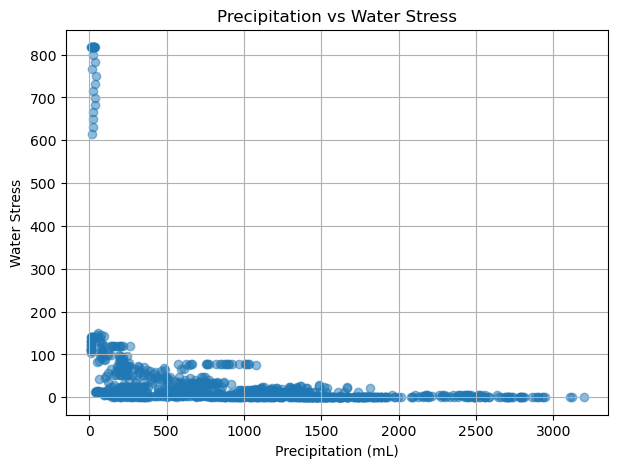

In [15]:
scatter_df = df[["Precipitation", "Water Stress"]].dropna()
plt.figure(figsize=(7,5))
plt.scatter(scatter_df["Precipitation"], scatter_df["Water Stress"], alpha=0.5)
plt.title("Precipitation vs Water Stress")
plt.xlabel("Precipitation (mL)")
plt.ylabel("Water Stress")
plt.grid(True)
plt.show()

C:\Users\sidne\AppData\Local\Temp\ipykernel_12608\176605096.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scatter_df["Avg Temp"] = pd.to_numeric(scatter_df["Avg Temp"], errors="coerce")
C:\Users\sidne\AppData\Local\Temp\ipykernel_12608\176605096.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scatter_df["Precipitation"] = pd.to_numeric(scatter_df["Precipitation"], errors="coerce")


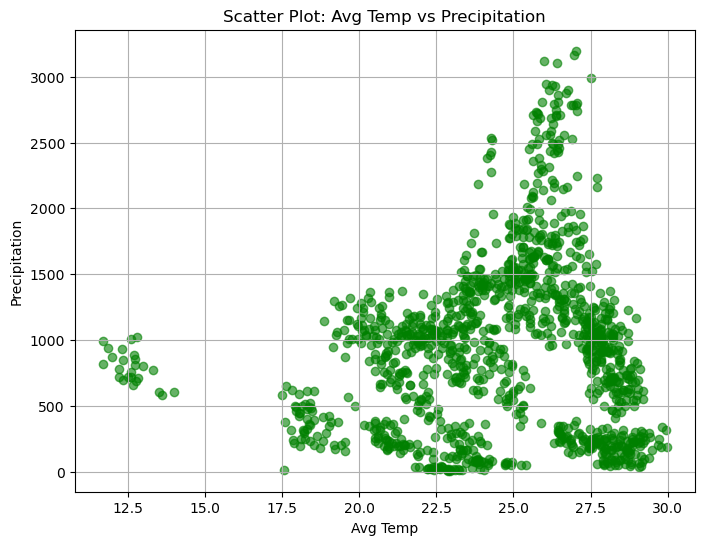

In [22]:
scatter_df = df.dropna(subset=["Avg Temp", "Precipitation"])

scatter_df["Avg Temp"] = pd.to_numeric(scatter_df["Avg Temp"], errors="coerce")
scatter_df["Precipitation"] = pd.to_numeric(scatter_df["Precipitation"], errors="coerce")

plt.figure(figsize=(8,6))
plt.scatter(scatter_df["Avg Temp"], scatter_df["Precipitation"], c='green', alpha=0.6)
plt.xlabel("Avg Temp")
plt.ylabel("Precipitation")
plt.title("Scatter Plot: Avg Temp vs Precipitation")
plt.grid(True)
plt.show()

## Spliting Data

In [11]:
FINAL_TEST_YEAR = 2025

test_df = df[df["Year"] == FINAL_TEST_YEAR].copy()
train_df = df[df["Year"] < FINAL_TEST_YEAR].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1296, 17)
Test shape: (54, 17)


In [23]:
categorical = df[["Country", "Year"]]
numerical = df.drop(columns=["Country", "Year"])